# Topics 3 & 4 — Training, Evaluation, Interpretation & Evaluation Strategies
### ITPU · Introduction to Machine Learning · Lessons A & B (one continuous coding companion)

This single notebook runs across **both lessons** so the coding tells one story:
**Topic 3** (how a model trains, overfitting, interpretability) flows straight into
**Topic 4** (how we evaluate it properly — cross-validation and metrics).

**What we'll code**
- **Topic 3 —** the training loop, the train/test gap, overfitting, reading a model with SHAP
- **Topic 4 —** cross-validation, and implementing classification & regression metrics by hand (AutoCode practice)

> Runs in Google Colab or Jupyter. Cells build on each other — run top to bottom.


In [1]:
# Setup — run me first
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)
print("Ready. NumPy", np.__version__)

Ready. NumPy 2.4.4


---
## Block 1 — What *training* involves

**The idea:** a model is `price = w * area + b`. Training means adjusting the **parameters** `w` and `b`
to make the predictions close to the real answers, measured by a **loss** (average squared error).

The **learning rate** is a **hyperparameter** — *we* choose it; the model does not learn it.


In [2]:
# Tiny dataset: apartment area (m2) -> price (k EUR)
area  = np.array([25, 40, 55, 70, 85, 100, 115], dtype=float)
price = np.array([35, 50, 68, 82, 98, 112, 130], dtype=float)   # roughly price = 0.9*area + 12

# Scale the feature to ~[-1,1] so the gradients for w and b are balanced.
# (Feature scaling is standard practice and keeps training stable.)
area_mean, area_std = area.mean(), area.std()
area_s = (area - area_mean) / area_std

# --- the model (works on the scaled feature) ---
def predict(a_scaled, w, b):
    return w * a_scaled + b

# --- the loss: mean squared error (how wrong we are) ---
def loss(w, b):
    err = predict(area_s, w, b) - price
    return np.mean(err ** 2)

# start with a BAD random guess
w, b = 0.0, 0.0
lr = 0.1            # learning rate  <-- HYPERPARAMETER (you set this)
print(f"Start: w={w:.3f} b={b:.3f}  loss={loss(w,b):.1f}")

Start: w=0.000 b=0.000  loss=7731.6


In [3]:
# --- the training loop: predict -> measure -> adjust -> repeat ---
history = []
for step in range(300):
    # gradients of the loss w.r.t. each parameter
    err = predict(area_s, w, b) - price
    grad_w = np.mean(2 * err * area_s)
    grad_b = np.mean(2 * err)
    # ADJUST the parameters a little, against the gradient
    w -= lr * grad_w
    b -= lr * grad_b
    history.append(loss(w, b))

print(f"Trained: w={w:.2f} b={b:.2f}  loss={loss(w,b):.2f}")
print("b ~ 82 = the average price; w ~ 33 = how much price moves per 1 std of area.")
print("Predictions now sit right on the data.")

Trained: w=31.36 b=82.14  loss=0.85
b ~ 82 = the average price; w ~ 33 = how much price moves per 1 std of area.
Predictions now sit right on the data.


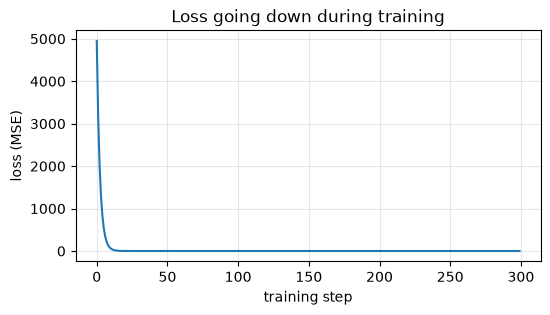

In [4]:
# Watch the loss fall — this curve IS 'training'
plt.figure(figsize=(6,3))
plt.plot(history)
plt.title("Loss going down during training")
plt.xlabel("training step"); plt.ylabel("loss (MSE)")
plt.grid(alpha=.3); plt.show()

> **Try it (live):** change `lr` to `0.5` — training is faster. Change it to `1.5` — the loss **explodes**
> (the nudges overshoot). That's why the learning rate is a hyperparameter you must tune.
>
> **Parameters** (`w`, `b`) are learned *inside* the loop. **Hyperparameters** (`lr`, number of steps) are set *outside* it.


---
## Block 2 — Evaluate on **unseen** data

**The mistake:** judging a model by how well it does on the data it *trained* on.
A model can score almost perfectly on training data and still fail on new data.

**The fix:** split the data — train on one part, test on another it has never seen. The **gap** between
train and test performance is your early warning of overfitting.


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score

# a small, slightly noisy classification dataset
X, y = make_moons(n_samples=300, noise=0.35, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# a very deep tree -> it can memorise the training data
model = DecisionTreeClassifier(max_depth=None, random_state=0)
model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test,  model.predict(X_test))
print(f"Training accuracy: {train_acc:.2%}")
print(f"Test accuracy:     {test_acc:.2%}")
print(f"GAP: {train_acc - test_acc:.2%}  <-- big gap = overfitting")

Training accuracy: 100.00%
Test accuracy:     84.44%
GAP: 15.56%  <-- big gap = overfitting


**Discuss:** the training accuracy looks amazing, but the test accuracy is much lower.
The model memorised the training points instead of learning the general pattern. *This is overfitting.*


---
## Block 3 — Overfitting / underfitting & the bias–variance trade-off

Let's *see* it: as we increase model complexity (tree depth), training error keeps falling,
but test error falls, bottoms out, then rises again. The bottom of the test curve is the **sweet spot**.


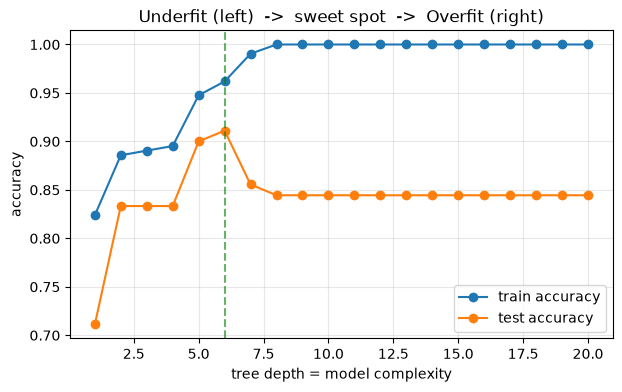

Best generalisation around depth = 6 (highest test accuracy).


In [6]:
depths = range(1, 21)
train_scores, test_scores = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=0).fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  m.predict(X_test)))

plt.figure(figsize=(7,4))
plt.plot(list(depths), train_scores, 'o-', label="train accuracy")
plt.plot(list(depths), test_scores,  'o-', label="test accuracy")
best = int(np.argmax(test_scores))
plt.axvline(list(depths)[best], ls='--', color='green', alpha=.6)
plt.title("Underfit (left)  ->  sweet spot  ->  Overfit (right)")
plt.xlabel("tree depth = model complexity"); plt.ylabel("accuracy")
plt.legend(); plt.grid(alpha=.3); plt.show()
print(f"Best generalisation around depth = {list(depths)[best]} (highest test accuracy).")

**Read the graph together:**
- **Left (shallow tree):** both scores low → **underfitting** (high bias).
- **Right (deep tree):** train ~100%, test drops → **overfitting** (high variance).
- **Green line:** best depth — lowest generalisation error. *This is the bias–variance trade-off.*

> Pair this with the interactive **Bias–Variance Explorer** (HTML) shown on screen.


---
## Block 4 — Interpretability: *reading* a model

Some models are **interpretable by design** (a shallow tree, linear regression); others are opaque.
**Model-agnostic** methods explain any model. The most common in practice is **SHAP**
(how much each feature pushed a prediction up or down).

Here we *read* feature importance — we don't derive the math. Focus on the story the chart tells.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# a dataset with named features so importances are meaningful
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
Xb, yb = data.data, data.target
rf = RandomForestClassifier(n_estimators=200, random_state=0).fit(Xb, yb)

imp = pd.Series(rf.feature_importances_, index=data.feature_names).sort_values()[-10:]
plt.figure(figsize=(7,4))
imp.plot(kind='barh', color='#38bdf8')
plt.title("Top 10 features driving the prediction (global importance)")
plt.xlabel("importance"); plt.tight_layout(); plt.show()
print("Read it: the longest bars are the features the model relies on most.")

**Real SHAP — the beeswarm summary plot.** This installs SHAP, explains the model, and shows
*every feature's push for every patient* in one plot. Read it, don't derive it.


In [ ]:
# Real SHAP beeswarm. First run installs the library (~20s in Colab).
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "shap"])
    import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(Xb[:100])

# Modern SHAP returns shape (samples, features, classes) for classifiers.
# Pick the "positive class" (class 1) so we get one push per feature.
import numpy as np
if isinstance(shap_values, list):
    sv = shap_values[1]
elif getattr(shap_values, "ndim", 2) == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

shap.summary_plot(sv, Xb[:100], feature_names=data.feature_names, max_display=10)

**How to read the beeswarm (do this together):**
- Each **row** is a feature, ranked by overall importance (top = matters most).
- Each **dot** is one patient. **Right** of centre = pushed the prediction up; **left** = pushed it down.
- **Colour** = the feature's value (red = high, blue = low). So you can say things like
  *"high 'worst radius' (red dots on the right) strongly pushes the prediction toward malignant."*

That's interpretability: not just *what* the model predicts, but *why*.


---
## Block 5 — Case study: *diagnose this model* (team task)

For each scenario, decide: **underfitting, overfitting, or good fit** — and what you'd do next.


In [ ]:
scenarios = [
    ("A", 0.98, 0.62),   # train, test
    ("B", 0.71, 0.69),
    ("C", 0.93, 0.90),
]
print("Scenario | Train | Test | Your diagnosis?")
for name, tr, te in scenarios:
    print(f"   {name}     | {tr:.0%}  | {te:.0%} |  ______________")

# Discuss in your breakout room, then reveal the hint below.

<details><summary><b>Reveal the diagnoses (after discussion)</b></summary>

- **A — Overfitting.** Huge train–test gap. Fix: simpler model, more data, regularisation, or fewer features.
- **B — Underfitting.** Both scores low and close. Fix: more complex model, better features, train longer.
- **C — Good fit.** Both high and close — it generalises. Ship it (and keep monitoring).
</details>

### Topic 3 wrap-up
- Training = adjust **parameters** to minimise **loss**; **hyperparameters** are set by you.
- Always judge a model on **unseen** data — mind the **gap**.
- **Underfit** = too simple (high bias); **overfit** = too complex (high variance); aim for the sweet spot.
- Prefer **interpretable** models where you can; otherwise explain them with **SHAP**.

---
---
# Topic 4 — Model Evaluation Strategies
### (same notebook — we continue the story)

In Topic 3 we judged a model with **one** train/test split. That works, but the score depends on *which* points
happened to land in the test set. **Topic 4** makes evaluation systematic:

1. **Cross-validation** — evaluate on *every* part of the data, not one lucky split.
2. **Classification metrics** — accuracy, precision, recall, F1.
3. **Regression metrics** — MSE/RMSE, MAE, MAPE, R².

> **Practice format:** the three exercises below mirror your **AutoCode** tasks. Each has **broken/blank code**,
> a **self-check** you can run, and a **hidden solution**. Use **NumPy only** (no sklearn) — exactly like AutoCode.
> NumPy refresher: https://cs231n.github.io/python-numpy-tutorial/#numpy


## 4.0 — Why cross-validation beats a single split

A single split gives **one** score that swings depending on the random split. **K-fold cross-validation**
splits the data into K parts, uses each part as the validation set once, and **averages** the K scores —
a far more reliable estimate.


In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier

# reuse the moons data from Topic 3 (X, y already defined above)
model = DecisionTreeClassifier(max_depth=4, random_state=0)

# one split gave a single number; 5-fold gives five, then we average
scores = cross_val_score(model, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=0))
print("5 fold scores:", np.round(scores, 3))
print(f"Average: {scores.mean():.3f}   (+/- {scores.std():.3f})")
print("The average is what you report — not a single lucky split.")

**The five strategies (see the Excalidraw board on screen):**
- **K-Fold** — default; K equal folds, each validates once.
- **Leave-One-Out** — K = N; each point validated alone (small data).
- **Stratified K-Fold** — keeps class balance in each fold (imbalanced data).
- **Grouped K-Fold** — keeps groups together (patients, users).
- **Time-Series** — always train on the past, validate on the future (ordered data).

**Engaging question:** which strategy for data that is *time-dependent*? *imbalanced*? *naturally grouped*?


---
## 🧩 Exercise 1 — Classification metrics (NumPy only)

Given true labels `y_true` and predicted labels `y_pred` (both 0/1), implement the four core metrics
from their definitions. Fill in the `# YOUR CODE HERE` lines.

| Metric | Formula |
|---|---|
| Accuracy | (TP + TN) / all |
| Precision | TP / (TP + FP) |
| Recall | TP / (TP + FN) |
| F1 | 2 · precision · recall / (precision + recall) |


In [ ]:
import numpy as np

def confusion_counts(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN

def accuracy(y_true, y_pred):
    TP, TN, FP, FN = confusion_counts(y_true, y_pred)
    # YOUR CODE HERE
    return ______

def precision(y_true, y_pred):
    TP, TN, FP, FN = confusion_counts(y_true, y_pred)
    # YOUR CODE HERE  (careful: TP + FP could be 0)
    return ______

def recall(y_true, y_pred):
    TP, TN, FP, FN = confusion_counts(y_true, y_pred)
    # YOUR CODE HERE
    return ______

def f1_score(y_true, y_pred):
    p, r = precision(y_true, y_pred), recall(y_true, y_pred)
    # YOUR CODE HERE
    return ______

In [ ]:
# --- self-check (run to test your work) ---
yt = [1,1,1,0,0,0,1,0]
yp = [1,0,1,0,1,0,1,0]
# expected: acc=0.75, prec=0.75, rec=0.75, f1=0.75
print("accuracy :", accuracy(yt, yp))
print("precision:", precision(yt, yp))
print("recall   :", recall(yt, yp))
print("f1       :", f1_score(yt, yp))

<details><summary><b>Solution (open after trying)</b></summary>

```python
def accuracy(y_true, y_pred):
    TP, TN, FP, FN = confusion_counts(y_true, y_pred)
    return (TP + TN) / (TP + TN + FP + FN)

def precision(y_true, y_pred):
    TP, TN, FP, FN = confusion_counts(y_true, y_pred)
    return TP / (TP + FP) if (TP + FP) else 0.0

def recall(y_true, y_pred):
    TP, TN, FP, FN = confusion_counts(y_true, y_pred)
    return TP / (TP + FN) if (TP + FN) else 0.0

def f1_score(y_true, y_pred):
    p, r = precision(y_true, y_pred), recall(y_true, y_pred)
    return 2*p*r / (p + r) if (p + r) else 0.0
```
**Precision vs recall:** precision = "when we say positive, how often are we right?"; recall = "of all real positives, how many did we catch?"
</details>


---
## 🧩 Exercise 2 — Regression metrics (NumPy only)

Given true values `y_true` and predictions `y_pred` (real numbers), implement each metric.

| Metric | Formula |
|---|---|
| MSE | mean( (y_true − y_pred)² ) |
| RMSE | √MSE |
| MAE | mean( \|y_true − y_pred\| ) |
| MAPE | mean( \|(y_true − y_pred) / y_true\| ) · 100 |
| R² | 1 − SS_res / SS_tot |


In [ ]:
import numpy as np

def mse(y_true, y_pred):
    y_true, y_pred = np.array(y_true, float), np.array(y_pred, float)
    # YOUR CODE HERE
    return ______

def rmse(y_true, y_pred):
    # YOUR CODE HERE  (hint: reuse mse)
    return ______

def mae(y_true, y_pred):
    y_true, y_pred = np.array(y_true, float), np.array(y_pred, float)
    # YOUR CODE HERE
    return ______

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, float), np.array(y_pred, float)
    # YOUR CODE HERE  (return a percentage)
    return ______

def r2_score(y_true, y_pred):
    y_true, y_pred = np.array(y_true, float), np.array(y_pred, float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    # YOUR CODE HERE
    return ______

In [ ]:
# --- self-check ---
yt = [100, 200, 300, 400]
yp = [110, 190, 320, 380]
print("MSE :", mse(yt, yp))     # 250.0
print("RMSE:", rmse(yt, yp))    # ~15.81
print("MAE :", mae(yt, yp))     # 15.0
print("MAPE:", round(mape(yt, yp), 2), "%")   # ~6.67 %
print("R2  :", round(r2_score(yt, yp), 4))    # ~0.98

<details><summary><b>Solution (open after trying)</b></summary>

```python
def mse(y_true, y_pred):
    y_true, y_pred = np.array(y_true, float), np.array(y_pred, float)
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    y_true, y_pred = np.array(y_true, float), np.array(y_pred, float)
    return np.mean(np.abs(y_true - y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, float), np.array(y_pred, float)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def r2_score(y_true, y_pred):
    y_true, y_pred = np.array(y_true, float), np.array(y_pred, float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot
```
**R² reads as:** fraction of the variation the model explains (1 = perfect, 0 = no better than the mean).
</details>


---
## 🧩 Exercise 3 — Cross-validation splits (NumPy only)

Implement **K-Fold** index splitting from scratch: given `n` samples and `k` folds, return a list of
`(train_idx, val_idx)` pairs. Then implement the **time-series** version where validation is always *after* training.


In [ ]:
import numpy as np

def kfold_indices(n, k):
    """Return list of (train_idx, val_idx) for K contiguous folds."""
    indices = np.arange(n)
    fold_sizes = np.full(k, n // k, dtype=int)
    fold_sizes[: n % k] += 1          # distribute the remainder
    splits, current = [], 0
    for fs in fold_sizes:
        val_idx = indices[current: current + fs]
        # YOUR CODE HERE: train_idx = everything except val_idx
        train_idx = ______
        splits.append((train_idx, val_idx))
        current += fs
    return splits

def timeseries_splits(n, k):
    """Expanding window: each split trains on the past, validates on the next block."""
    fold = n // (k + 1)
    splits = []
    for i in range(1, k + 1):
        train_idx = np.arange(0, fold * i)
        val_idx   = np.arange(fold * i, fold * (i + 1))
        # YOUR CODE HERE: append the (train_idx, val_idx) pair
        ______
    return splits

In [ ]:
# --- self-check ---
splits = kfold_indices(10, 5)
print("K-Fold: 5 folds from 10 points")
for i, (tr, va) in enumerate(splits):
    print(f"  fold {i+1}: val={va.tolist()}  train has {len(tr)} pts")

print("\nTime-series: train always before validation")
for i, (tr, va) in enumerate(timeseries_splits(12, 3)):
    print(f"  split {i+1}: train={tr.tolist()}  val={va.tolist()}")

<details><summary><b>Solution (open after trying)</b></summary>

```python
def kfold_indices(n, k):
    indices = np.arange(n)
    fold_sizes = np.full(k, n // k, dtype=int)
    fold_sizes[: n % k] += 1
    splits, current = [], 0
    for fs in fold_sizes:
        val_idx = indices[current: current + fs]
        train_idx = np.concatenate([indices[:current], indices[current + fs:]])
        splits.append((train_idx, val_idx))
        current += fs
    return splits

def timeseries_splits(n, k):
    fold = n // (k + 1)
    splits = []
    for i in range(1, k + 1):
        train_idx = np.arange(0, fold * i)
        val_idx   = np.arange(fold * i, fold * (i + 1))
        splits.append((train_idx, val_idx))
    return splits
```
**Key idea:** in time-series, `train_idx` is always the earlier indices and `val_idx` the later ones — never shuffle.
</details>

### Topic 4 wrap-up
- **Cross-validation** averages over many splits → a reliable score; match the **strategy** to the data.
- **Classification:** accuracy / precision / recall / F1 (precision vs recall is the key trade-off).
- **Regression:** MSE·RMSE / MAE / MAPE / R² (R² = variation explained).
- Now complete the same three exercises in **AutoCode** — the unit tests there check these exact functions.
